# Tennis Player Actions EDA - Hanyi

Within this notebook, we aim to conduct exploratory data analysis on the Tennis Players Actions dataset from Kaggle, available at: [Tennis Player Actions Dataset](https://www.kaggle.com/datasets/orvile/tennis-player-actions-dataset/data).

## Setup
Required dependencies:

In [1]:
!pip3 install kagglehub

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


Move to root directory:

In [5]:
import os

if os.path.basename(os.getcwd()) == "eda":
    os.chdir("..")

print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection


We begin by downloading the dataset from kagglehub:

In [7]:
import kagglehub
import os

# Set download path to root dir, kagglehub automatically creates datasets subdir
os.environ["KAGGLEHUB_CACHE"] = ""

# Download latest version
path = kagglehub.dataset_download("orvile/tennis-player-actions-dataset")

print("Path to dataset files:", path)

100%|██████████| 503M/503M [00:14<00:00, 35.2MB/s] 

Extracting files...


Path to dataset files: datasets/orvile/tennis-player-actions-dataset/versions/1


Now, we load the dataset into a pandas df:

In [19]:
import json
import pandas as pd

def init_df(pose: str, show_info: bool = True):
    with open(f"{path}/Tennis Player Actions Dataset for Human Pose Estimation/annotations/{pose}.json") as f:
        pose_data = json.load(f)
    data_dict = {}
    data_dict["images"] = pd.DataFrame(pose_data["images"])
    data_dict["categories"] = pd.DataFrame(pose_data["categories"])
    data_dict["annotations"] = pd.DataFrame(pose_data["annotations"])

    if show_info:
        print(f"\n{'='*50}")
        print(f"Pose: {pose}")
        print(f"Images: {len(data_dict['images'])}")
        print(f"Categories: {len(data_dict['categories'])}")
        print(f"Annotations: {len(data_dict['annotations'])}\n")
        print(f"Images head:\n{data_dict['images'].head(1)}\n")
        print(f"Categories:\n{data_dict['categories']}\n")
        print(f"Annotations head:\n{data_dict['annotations'].head(1)}\n")
        print(f"{'='*50}\n")

    return data_dict

backhand_data = init_df("backhand")
forehand_data = init_df("forehand", show_info=False)
ready_position_data = init_df("ready_position", show_info=False)
serve_data = init_df("serve", show_info=False)





Pose: backhand
Images: 500
Categories: 1
Annotations: 500

Images head:
      id  dataset_id                           path  width  height   file_name
0  10001          10  ../images/backhand/B_001.jpeg   1280     720  B_001.jpeg

Categories:
   id      name                                          keypoints  \
0   5  Backhand  [nose, left_eye, right_eye, left_ear, right_ea...   

                                            skeleton  
0  [[1, 2], [1, 3], [1, 18], [2, 4], [3, 5], [6, ...  

Annotations head:
     id  image_id  category_id  \
0  3501     10001            5   

                                        segmentation   area  \
0  [[667.9, 257.3, 667.9, 467.4, 496.4, 467.4, 49...  36120   

                           bbox  iscrowd  isbbox  \
0  [496.0, 257.0, 172.0, 210.0]    False    True   

                                           keypoints  num_keypoints color  
0  [601, 291, 1, 596, 288, 1, 605, 286, 1, 592, 2...             18   NaN  




From importing the dataset, we see it is split into four classes:
1. Backhand
2. Forehand
3. Ready position
4. Serve

Looking at the annotation df, we note the important fields are "segmentation", "bbox", and "keypoints":
- Segmentation is the image segmentation mask of the player, which is a polygon that shows where in the image the player is.
- Bbox is the bounding box of the player, a rectangular box that encloses the player.
- Keypoints are the 18 keypoints that outline the specific vertices of a player, such as their head, hand, or feet. In COCO, keypoints are the vertices, while the skeletons are the edges that connects the keypoints.

In [20]:
backhand_data["annotations"].head(1)

,id,image_id,category_id,segmentation,area,bbox,iscrowd,isbbox,keypoints,num_keypoints,color
0,3501,10001,5,"[[667.9, 257.3, 667.9, 467.4, 496.4, 467.4, 49...",36120,"[496.0, 257.0, 172.0, 210.0]",False,True,"[601, 291, 1, 596, 288, 1, 605, 286, 1, 592, 2...",18,NaN


## Numeric Columns
First, we'll analyze the numeric columns:

In [29]:
backhand_data["annotations"].select_dtypes(include="number").agg(['min', 'max'])

,id,image_id,category_id,area,num_keypoints
min,3501,10001,5,0,16
max,4000,10500,5,142881,18


In [23]:
forehand_data["annotations"].select_dtypes(include="number").agg(['min', 'max'])

,id,image_id,category_id,area,num_keypoints
min,4001,10501,6,13980,17
max,5502,11000,6,145803,18


In [24]:
ready_position_data["annotations"].select_dtypes(include="number").agg(['min', 'max'])

,id,image_id,category_id,area,num_keypoints
min,4500,11001,7,11773,17
max,4999,11500,7,120218,18


In [25]:
serve_data["annotations"].select_dtypes(include="number").agg(['min', 'max'])

,id,image_id,category_id,area,num_keypoints
min,5000,11501,8,0,17
max,5501,12000,8,66123,18


We note that the numeric fields are:
- `id`: The annotation ID of the current sample. Maps 1:1 with `image_id`. Ranges from 3501 to 5501, where each class is sorted in ascending order.
- `image_id`: The image ID of the current sample. Same attributes as `id`, but ranges from 10001 to 12000.
- `category_id`: The class ID of each sample. 5 = backhand, 6 = forehand, 7 = ready position, 8 = serve.
- `area`: The area of the bbox, not the segmentation mask.
- `num_keypoints`: The number of vertices for the pose skeleton of the current sample. There are 18 defined vertices, but some samples may have up to 2 missing.

## Array Columns

The other important fields are mostly arrays of numeric values.

In [37]:
def compute_range(df: pd.DataFrame, cols: list[str] = ["segmentation", "bbox", "keypoints"]):
    print(f"{'='*50}")
    for col in cols:
        lengths = df[col].apply(len)
        print(f"{col}: min={lengths.min()}, max={lengths.max()}")
    print(f"{'='*50}\n")

print("Backhand:")
compute_range(backhand_data["annotations"])

print("Forehand:")
compute_range(forehand_data["annotations"])

print("Ready position:")
compute_range(ready_position_data["annotations"])

print("Serve:")
compute_range(serve_data["annotations"])

Backhand:
segmentation: min=0, max=1
bbox: min=4, max=4
keypoints: min=54, max=54

Forehand:
segmentation: min=1, max=1
bbox: min=4, max=4
keypoints: min=54, max=54

Ready position:
segmentation: min=1, max=1
bbox: min=4, max=4
keypoints: min=54, max=54

Serve:
segmentation: min=0, max=1
bbox: min=4, max=4
keypoints: min=54, max=54



In [ ]:
def compute_seg_range(df: pd.DataFrame):
    print(f"{'='*50}")
    lengths = df["segmentation"].apply(lambda seg: [len(poly) for poly in seg])
    print(f"first segmentation mask: min={lengths.min()}, max={lengths.max()}")
    print(f"{'='*50}\n")

print("Backhand:")
compute_seg_range(backhand_data["annotations"])

print("Forehand:")
compute_seg_range(forehand_data["annotations"])

print("Ready position:")
compute_seg_range(ready_position_data["annotations"])

print("Serve:")
compute_seg_range(serve_data["annotations"])

Backhand:


TypeError: object of type 'float' has no len()

Each field here means:
- `segmentation`: An array of masks, where each mask is a polygon made up of an array of coordinates in the format [x1, y1, x2, y2, ...].
- `bbox`: An array of bounding boxes, where each box is defined by [x, y, width, height].
- `keypoints`: An array of keypoints for the pose of the player, which is in the format [x1, y1, v1, x2, y2, v2, ...].

Segmentation has a max length of 1 because we're only masking one object here: the player. We can assume that when its length is 0 it means there is no mask for that sample. 

Bbox's only length is 4, which makes sense because it's a rectangular box. 

Keypoints also only has length of 54. This is because each vertex has three values associated with it: x, y, and visibility (denoteed as v). 54 / 3 = 18, which is the number of vertices we have. For each vertex, x and y is its position, while v is a 3-state label where 0 = not in image, 1 = in image but not visible, 2 = in image and visible.

## Other Columns

The only columns remaining are:

- `iscrowd`: binary denoting if the bbox is a group of objects. Irrevant for our case, since we only have one player.
- `isbbox`: ?
- `color`: the color of the bbox to be used for visualization?

We can analyze the bool values first:

In [43]:
def count_bool_occurs(df: pd.DataFrame, cols: list[str] = ["iscrowd", "isbbox"]):
    print(f"{'='*50}")
    for col in cols:
        print(df[col].value_counts())
    print(f"{'='*50}\n")

print("Backhand:")
count_bool_occurs(backhand_data["annotations"])

print("Forehand:")
count_bool_occurs(forehand_data["annotations"])

print("Ready position:")
count_bool_occurs(ready_position_data["annotations"])

print("Serve:")
count_bool_occurs(serve_data["annotations"])

Backhand:
iscrowd
False    500
Name: count, dtype: int64
isbbox
True     496
False      4
Name: count, dtype: int64

Forehand:
iscrowd
False    500
Name: count, dtype: int64
isbbox
True    500
Name: count, dtype: int64

Ready position:
iscrowd
False    500
Name: count, dtype: int64
isbbox
True    500
Name: count, dtype: int64

Serve:
iscrowd
False    500
Name: count, dtype: int64
isbbox
True     498
False      2
Name: count, dtype: int64



As expected, iscrowd is always false for all our samples.

Isbbox has 6 negatives, which doesn't intuitively make sense since we had values for all bbox cols. Will do more visual analysis to understand this.

For the color field, we can begin by counting all unique values:

In [48]:
def sho(df: pd.DataFrame, cols: list[str] = ["iscrowd", "isbbox"]):
    print(f"{'='*50}")
    for col in cols:
        print(df[col].value_counts())
    print(f"{'='*50}\n")

print("Backhand:")
print(backhand_data["annotations"]["color"].nunique())

print("Forehand:")
print(forehand_data["annotations"]["color"].nunique())

print("Ready position:")
print(ready_position_data["annotations"]["color"].nunique())

print("Serve:")
print(serve_data["annotations"]["color"].nunique())


all_annotations = pd.concat(
    [backhand_data["annotations"], forehand_data["annotations"], ready_position_data["annotations"], serve_data["annotations"]],
    axis=0,
    ignore_index=True,
)

print("All annotations:")
print(all_annotations["color"].nunique())

Backhand:
499
Forehand:
500
Ready position:
500
Serve:
500
All annotations:
1999


There seems to be a unique color for each sample in the dataset.

## Quantitative Analysis Summary
With each column analyzed quantitatively, we can conclude that each annotation is a dictionary with the following columns:

- `id`: The annotation ID of the current sample. Maps 1:1 with `image_id`. Ranges from 3501 to 5501, where each class is sorted in ascending order.
- `image_id`: The image ID of the current sample. Same attributes as `id`, but ranges from 10001 to 12000.
- `category_id`: The class ID of each sample. 5 = backhand, 6 = forehand, 7 = ready position, 8 = 
serve.
- `segmentation`: An array of masks, where each mask is a polygon made up of an array of coordinates in the format [x1, y1, x2, y2, ...].
- `area`: The area of the bbox, not the segmentation mask.
- `bbox`: An array of bounding boxes, where each box is defined by [x, y, width, height].
- `iscrowd`: binary denoting if the bbox is a group of objects. Irrevant for our case, since we only have one player.
- `isbbox`: ?
- `keypoints`: An array of keypoints for the pose of the player, which is in the format [x1, y1, v1, x2, y2, v2, ...]. For each vertex, x and y is its position, while v is a 3-state label where 0 = not in image, 1 = in image but not visible, 2 = in image and visible.
- `num_keypoints`: The number of vertices for the pose skeleton of the current sample. There are 18 defined vertices, but some samples may have up to 2 missing.
- `color`: A unique color for each sample.

## Visualization

To reinforce understanding and explain some of the uncertain columns (`isbbox`, `color`), we can visualize some of the images and their annotations.

Current working directory: /Users/hanyiliu/Documents/GitHub/tennis-pose-detection
BBox: [483, 241, 126, 219]
Segmentation: [[608.8, 241.4, 608.8, 459.7, 483.1, 459.7, 483.1, 241.4]]
Keypoints: [544, 268, 1, 538, 262, 1, 546, 261, 1, 538, 270, 2, 554, 266, 2, 544, 281, 2, 541, 278, 1, 543, 314, 2, 536, 308, 1, 518, 332, 2, 519, 338, 1, 563, 351, 2, 584, 347, 1, 556, 395, 2, 564, 391, 2, 581, 441, 2, 582, 423, 2, 549, 273, 2]


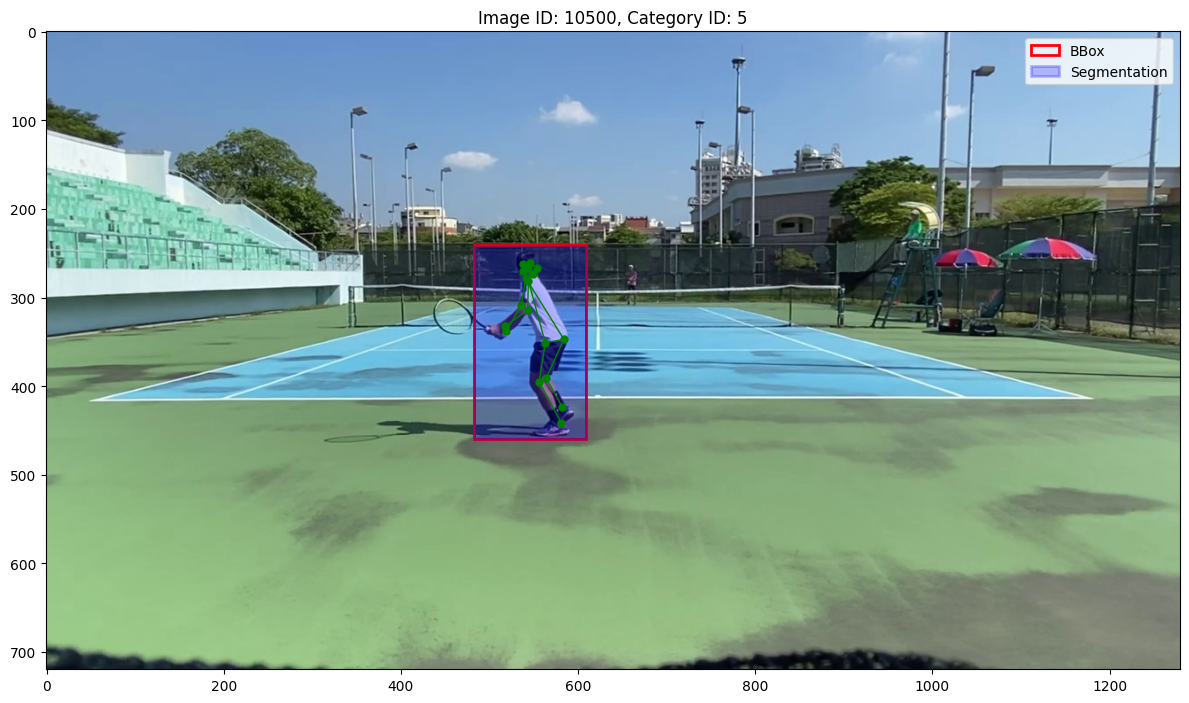

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_annotation(annotation, data_dict, image_dir=None, keypoint_skeleton=None):
    """
    Visualize a single annotation with bbox, segmentation mask, and pose skeleton.
    
    Parameters:
    - annotation: a row from the annotations dataframe
    - data_dict: dict containing "images" and "categories" dataframes
    - image_dir: optional path override to the images directory
    - keypoint_skeleton: optional list of tuples defining skeleton connections
    """
    image_df = data_dict["images"]

    # Get image info
    image_id = annotation['image_id']
    image_info = image_df[image_df['id'] == image_id].iloc[0]
    image_rel = image_info['path']
    if image_rel.startswith("../"):
        image_rel = image_rel[3:]
    image_path = os.path.normpath(
        os.path.join(path, "Tennis Player Actions Dataset for Human Pose Estimation", image_rel)
    )

    # Build skeleton automatically if not provided
    if keypoint_skeleton is None:
        categories_df = data_dict["categories"]
        raw_skeleton = categories_df.iloc[0]["skeleton"]
        keypoint_skeleton = [(a - 1, b - 1) for a, b in raw_skeleton]
    
    # Load image
    img = Image.open(image_path)
    img_array = np.array(img)
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(img_array)
    
    # Draw bbox
    bbox = annotation['bbox']
    rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], 
                             linewidth=2, edgecolor='r', facecolor='none', label='BBox')
    ax.add_patch(rect)
    
    # Draw segmentation mask (polygon)
    seg = annotation['segmentation']
    if seg and len(seg) > 0:
        if isinstance(seg[0], (int, float)):
            seg_polys = [seg]
        else:
            seg_polys = seg
        for mask in seg_polys:
            mask_array = np.array(mask).reshape(-1, 2)
            polygon = patches.Polygon(
                mask_array,
                closed=True,
                linewidth=2,
                edgecolor='b',
                facecolor='b',
                alpha=0.25,
                label='Segmentation'
            )
            ax.add_patch(polygon)
    
    # Draw keypoints and skeleton
    keypoints = annotation['keypoints']
    keypoints_array = np.array(keypoints).reshape(-1, 3)
    
    # Plot keypoints
    for i, (x, y, v) in enumerate(keypoints_array):
        if v > 0:  # Only plot visible keypoints
            ax.plot(x, y, 'go', markersize=5)
    
    # Plot skeleton connections
    if keypoint_skeleton:
        for start_idx, end_idx in keypoint_skeleton:
            x_start, y_start, v_start = keypoints_array[start_idx]
            x_end, y_end, v_end = keypoints_array[end_idx]
            if v_start > 0 and v_end > 0:
                ax.plot([x_start, x_end], [y_start, y_end], 'g-', linewidth=1)
    
    ax.set_title(f"Image ID: {image_id}, Category ID: {annotation['category_id']}")
    ax.legend()
    plt.tight_layout()

    print("BBox:", bbox)
    print("Segmentation:", seg)
    print("Keypoints:", keypoints)

    plt.show()

# Example: visualize first backhand annotation
visualize_annotation(backhand_data['annotations'].iloc[499], backhand_data)